# Model Evaluation - Twitter Sentiment Analysis

This notebook evaluates the trained sentiment analysis models using various metrics and visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    roc_auc_score
)
from sklearn.model_selection import learning_curve
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
# Load the trained model and vectorizer
model = joblib.load('../models/sentiment_model.pkl')
vectorizer = joblib.load('../models/tfidf_vectorizer.pkl')
print("Model and vectorizer loaded successfully!")
print(f"Model type: {type(model).__name__}")

Model and vectorizer loaded successfully!
Model type: LogisticRegression


In [5]:
# Load test data

df = pd.read_csv(
    '../data/twitter_sentiment_sample.csv',
    encoding='latin-1',
    header=None,
    names=['target', 'ids', 'date', 'flag', 'user', 'text']
)
print(f"Dataset shape: {df.shape}")
print(f"\nSentiment distribution:")
print(df['target'].value_counts())

# Encode the raw target labels to the same 0/1/2 mapping used during training
if 'sentiment_encoded' not in df.columns:
    df['sentiment_encoded'] = df['target'].map({0: 0, 2: 1, 4: 2}).astype(int)

# Split features and labels
from sklearn.model_selection import train_test_split
import sys
from pathlib import Path

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from utils.preprocessing import preprocess_tweet

# Preprocess tweets
# Using the same preprocessing pipeline as training
processed_text = df['text'].apply(preprocess_tweet)
df['processed_text'] = processed_text
X = vectorizer.transform(df['processed_text'])
y = df['sentiment_encoded'].astype(int)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTest set size: {len(y_test)} samples")

Dataset shape: (1600000, 6)

Sentiment distribution:
target
0    800000
4    800000
Name: count, dtype: int64

Test set size: 320000 samples


In [6]:
# Make predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("📊 Model Performance Metrics:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

📊 Model Performance Metrics:
Accuracy:  0.7697
Precision: 0.7705
Recall:    0.7697
F1-Score:  0.7695


In [9]:
# Detailed classification report
target_names = ['Negative', 'Neutral', 'Positive']
print("\n📋 Detailed Classification Report:")
actual_labels = sorted(np.unique(np.concatenate([y_test.to_numpy(), y_pred])))
label_to_name = {0: 'Negative', 2: 'Positive'}
target_names = [label_to_name[label] for label in actual_labels]

print(classification_report(
    y_test,
    y_pred,
    labels=actual_labels,
    target_names=target_names,
    zero_division=0
))


📋 Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.74      0.76    160000
    Positive       0.76      0.80      0.78    160000

    accuracy                           0.77    320000
   macro avg       0.77      0.77      0.77    320000
weighted avg       0.77      0.77      0.77    320000



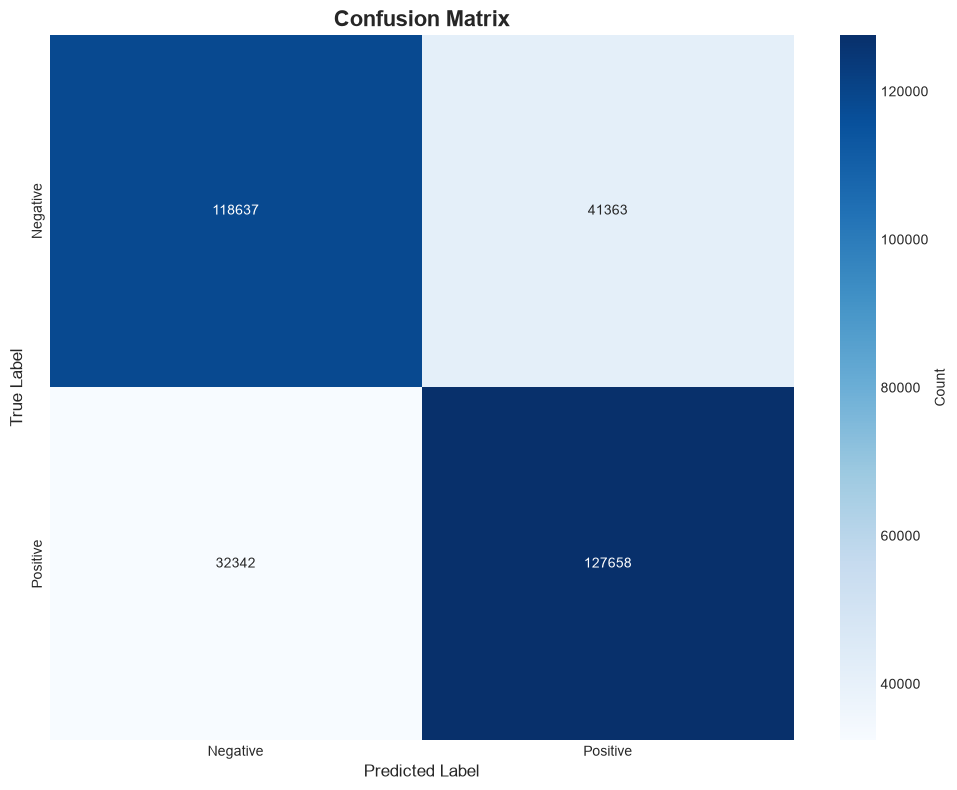

In [10]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

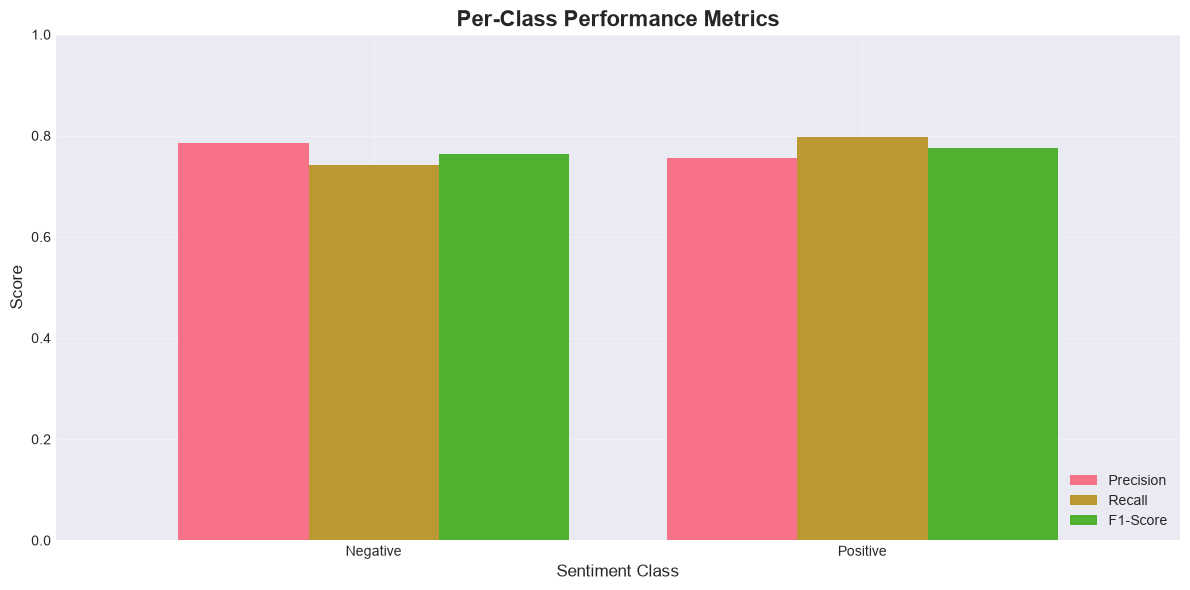

In [11]:
# Per-class metrics
class_precision = precision_score(y_test, y_pred, average=None)
class_recall = recall_score(y_test, y_pred, average=None)
class_f1 = f1_score(y_test, y_pred, average=None)

# Create DataFrame for visualization
metrics_df = pd.DataFrame({
    'Class': target_names,
    'Precision': class_precision,
    'Recall': class_recall,
    'F1-Score': class_f1
})

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
metrics_df.plot(x='Class', kind='bar', ax=ax, width=0.8)
plt.title('Per-Class Performance Metrics', fontsize=16, fontweight='bold')
plt.xlabel('Sentiment Class', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ylim(0, 1.0)
plt.legend(loc='lower right', fontsize=10)
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

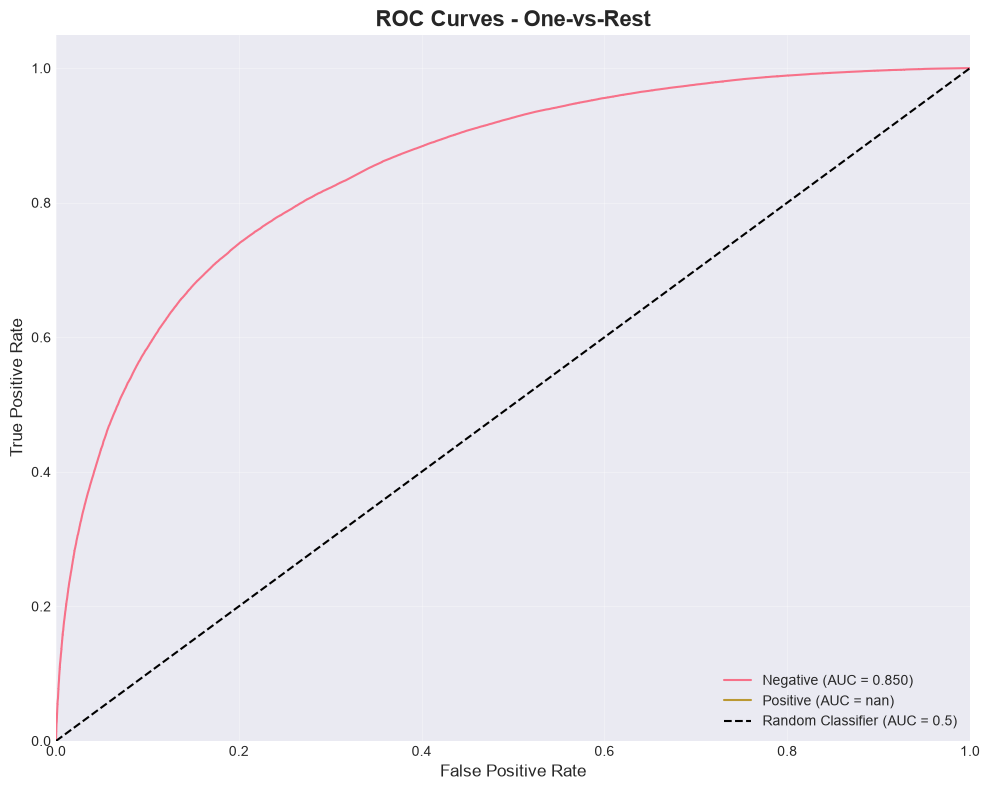

In [12]:
# ROC Curves (One-vs-Rest)
plt.figure(figsize=(10, 8))

for i, class_name in enumerate(target_names):
    # Create binary labels for each class
    y_test_binary = (y_test == i).astype(int)
    y_pred_binary = y_pred_proba[:, i]
    
    fpr, tpr, _ = roc_curve(y_test_binary, y_pred_binary)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - One-vs-Rest', fontsize=16, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

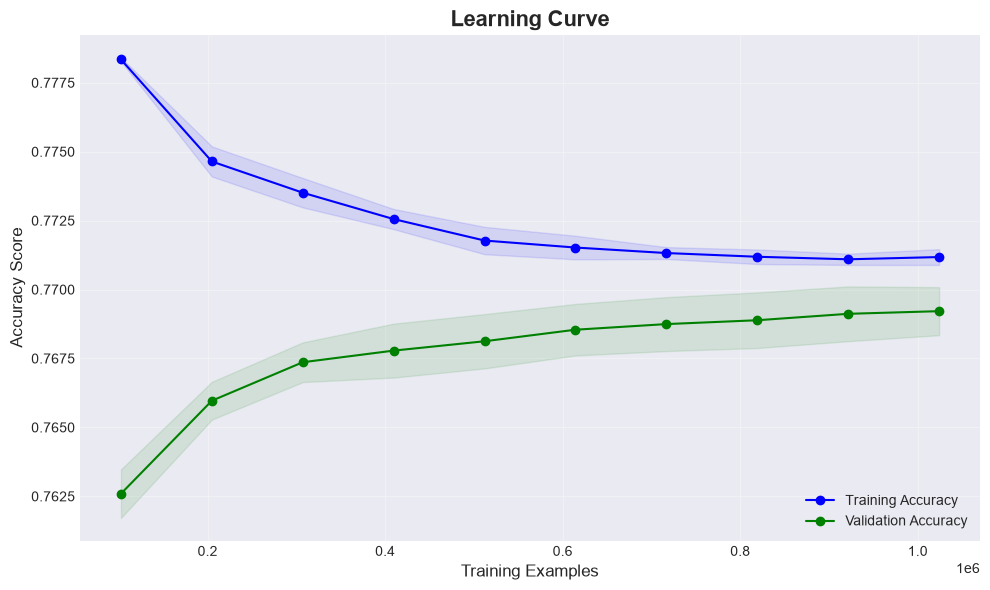

In [13]:
# Learning Curve Analysis
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10)):
    """
    Plot learning curves for the model
    """
    train_sizes_abs, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=cv, train_sizes=train_sizes,
        scoring='accuracy', n_jobs=-1
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes_abs, train_mean, 'o-', color='blue', label='Training Accuracy')
    plt.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, 
                     alpha=0.1, color='blue')
    plt.plot(train_sizes_abs, val_mean, 'o-', color='green', label='Validation Accuracy')
    plt.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std, 
                     alpha=0.1, color='green')
    
    plt.xlabel('Training Examples', fontsize=12)
    plt.ylabel('Accuracy Score', fontsize=12)
    plt.title('Learning Curve', fontsize=16, fontweight='bold')
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot learning curve
plot_learning_curve(model, X_train, y_train)

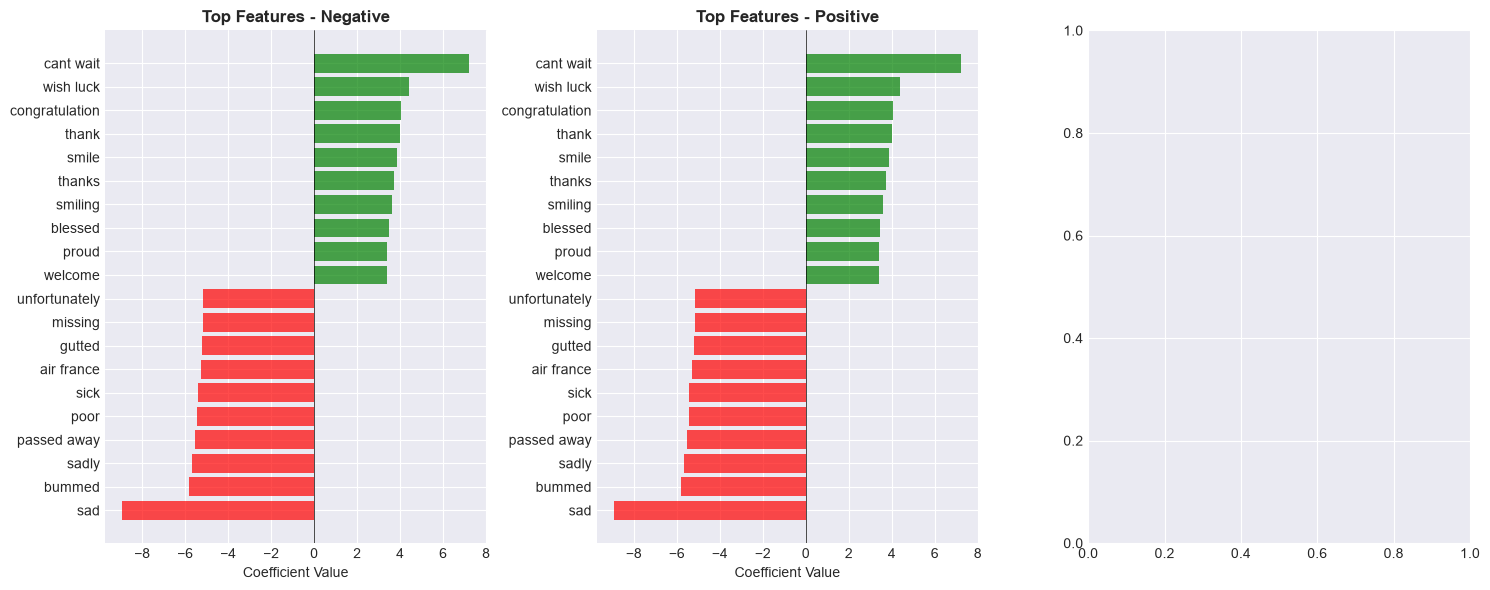

In [17]:
# Feature Importance (Top features by coefficient)
if hasattr(model, 'coef_'):
    feature_names = vectorizer.get_feature_names_out()
    coefficients = model.coef_
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 6))
    
    for idx, class_name in enumerate(target_names):
        # Get top positive and negative features for each class
        # Binary logistic regression stores only one coefficient vector, while
        # multiclass models store one per class.
        coef = coefficients[0] if coefficients.ndim == 1 or coefficients.shape[0] == 1 else coefficients[idx]
        top_positive = np.argsort(coef)[-10:]
        top_negative = np.argsort(coef)[:10]
        
        # Combine and plot
        ax = axes[idx]
        all_indices = np.concatenate([top_negative, top_positive])
        all_values = coef[all_indices]
        all_features = feature_names[all_indices]
        
        colors = ['red' if x < 0 else 'green' for x in all_values]
        y_pos = np.arange(len(all_features))
        
        ax.barh(y_pos, all_values, color=colors, alpha=0.7)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(all_features)
        ax.set_xlabel('Coefficient Value', fontsize=10)
        ax.set_title(f'Top Features - {class_name}', fontsize=12, fontweight='bold')
        ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    
    plt.tight_layout()
    plt.show()

In [20]:
# Prediction analysis on sample tweets
sample_tweets = [
    "I absolutely love this product! It's the best!",
    "This is terrible, I want a refund.",
    "It's okay, nothing special.",
    "Amazing service! Will definitely recommend!",
    "Waste of money, very disappointed."
]

print("🔍 Sample Predictions:")
print("=" * 80)
for tweet in sample_tweets:
    processed = preprocess_tweet(tweet)
    vectorized = vectorizer.transform([processed])
    prediction = model.predict(vectorized)[0]
    probabilities = model.predict_proba(vectorized)[0]
    
    sentiment = label_to_name.get(int(prediction), "Unknown")
    confidence = max(probabilities) * 100
    
    print(f"\nTweet: {tweet}")
    print(f"Sentiment: {sentiment}")
    print(f"Confidence: {confidence:.1f}%")
    class_probs = {
        label_to_name.get(label, f"Class {label}"): prob
        for label, prob in enumerate(probabilities)
    }
    print("Probabilities: " + ", ".join(
        f"{name}={value:.2%}" for name, value in class_probs.items()
    ))
    print("-" * 80)

🔍 Sample Predictions:

Tweet: I absolutely love this product! It's the best!
Sentiment: Positive
Confidence: 95.2%
Probabilities: Negative=4.78%, Class 1=95.22%
--------------------------------------------------------------------------------

Tweet: This is terrible, I want a refund.
Sentiment: Negative
Confidence: 97.7%
Probabilities: Negative=97.66%, Class 1=2.34%
--------------------------------------------------------------------------------

Tweet: It's okay, nothing special.
Sentiment: Positive
Confidence: 65.2%
Probabilities: Negative=34.80%, Class 1=65.20%
--------------------------------------------------------------------------------

Tweet: Amazing service! Will definitely recommend!
Sentiment: Positive
Confidence: 94.4%
Probabilities: Negative=5.62%, Class 1=94.38%
--------------------------------------------------------------------------------

Tweet: Waste of money, very disappointed.
Sentiment: Negative
Confidence: 98.2%
Probabilities: Negative=98.20%, Class 1=1.80%
----

In [22]:
# Error analysis
errors = y_test != y_pred
error_indices = np.where(errors)[0]

print(f"📊 Error Analysis:")
print(f"Total errors: {len(error_indices)} out of {len(y_test)} samples")
print(f"Error rate: {len(error_indices)/len(y_test):.2%}")

if len(error_indices) > 0:
    # Get some examples of misclassifications
    sample_errors = np.random.choice(error_indices, min(5, len(error_indices)), replace=False)
    
    print("\n📝 Sample Misclassifications:")
    print("=" * 80)
    for idx in sample_errors:
        # Get original tweet (we need to map back to original data)
        # For this demo, we'll use the processed text
        # Map the test-set position back to the original tweet row and label names
        test_row_idx = y_test.index[idx]
        tweet_text = df.loc[test_row_idx, 'text']

        true_label = label_to_name.get(int(y_test.iloc[idx]), "Unknown")
        pred_label = label_to_name.get(int(y_pred[idx]), "Unknown")

        print(f"\nTweet: {tweet_text}")
        print(f"True: {true_label}")
        print(f"Predicted: {pred_label}")
        print(f"True: {label_to_name.get(int(y_test.iloc[idx]), 'Unknown')}")
        print(f"Confidence: {max(y_pred_proba[idx])*100:.1f}%")
        print("-" * 80)

📊 Error Analysis:
Total errors: 73705 out of 320000 samples
Error rate: 23.03%

📝 Sample Misclassifications:

Tweet: @lkenner I saw your &quot;dieing&quot; tweet! I felt your pain.... 
True: Positive
Predicted: Negative
True: Positive
Confidence: 79.1%
--------------------------------------------------------------------------------

Tweet: just got out of work, hanging out then going to sleep, i have the next 3 days off! 
True: Positive
Predicted: Negative
True: Positive
Confidence: 61.5%
--------------------------------------------------------------------------------

Tweet: Watching KFP and just realized that it was D-Day today  wow...
True: Negative
Predicted: Positive
True: Negative
Confidence: 57.1%
--------------------------------------------------------------------------------

Tweet: i have to butting poop again 
True: Negative
Predicted: Positive
True: Negative
Confidence: 61.4%
--------------------------------------------------------------------------------

Tweet: Jenn i mis

In [23]:
# Summary statistics
print("📈 Model Performance Summary")
print("=" * 50)
print(f"Model Type: {type(model).__name__}")
print(f"Number of Classes: {len(target_names)}")
print(f"Feature Space: {X.shape[1]} features")
print(f"Overall Accuracy: {accuracy:.2%}")
print(f"Weighted F1-Score: {f1:.3f}")
print(f"Training Samples: {len(y_train)}")
print(f"Test Samples: {len(y_test)}")

print("\n✅ Model is ready for deployment!")
print("=" * 50)

📈 Model Performance Summary
Model Type: LogisticRegression
Number of Classes: 2
Feature Space: 3000 features
Overall Accuracy: 76.97%
Weighted F1-Score: 0.769
Training Samples: 1280000
Test Samples: 320000

✅ Model is ready for deployment!
